# Reconstructing the CMB TT Acoustic Phase Shift

#### Diego Miura, Yale College Class of 2027

**Abstract**

My final project will explore the neutrino-induced acoustic phase shift as a robust signature of free-streaming radiation. The phase shift is interesting because as shown in Follin 2015 (the same paper referenced in the class notes), it arises under very restrictive conditions. For adiabatic initial conditions, this would mean perturbations that propagate faster than the photon-baryon sound speed. This makes the phase shift a relatively clean probe of beyond-ΛCDM physics and less susceptible to degeneracies that affect things like overall amplitudes. As a focused starting point, I will work from the analysis framework and physical interpretation emphasized in Baumann 2016.

**Main references.** 
- Follin et al. (2015), *First Detection of the Acoustic Oscillation Phase Shift Expected from the Cosmic Neutrino Background*
- Baumann, Green, Meyers, and Wallisch (2017), *Phases of New Physics in the CMB*.

## What we're doing and why it matters

### The CMB as a snapshot of the early universe

The cosmic microwave background (CMB) is light released about 380,000 years after the Big Bang, when the universe cooled enough for electrons and protons to combine into neutral hydrogen. Before that moment, photons were trapped in a hot plasma of photons and baryons (mostly protons and electrons), bouncing off charged particles and unable to travel freely. When the plasma neutralized, the photons streamed out and have been traveling ever since.

That plasma was not perfectly uniform. Tiny (like truly tiny) density fluctuations, seeded by quantum processes during inflation, set up pressure waves in the photon-baryon fluid, much like sound waves. When the CMB was released, these waves were frozen in place. We observe them today as a pattern of peaks and troughs in the CMB temperature power spectrum, $D_\ell^{TT}$, plotted as a function of angular multipole $\ell$ (higher $\ell$ corresponds to smaller angular scales on the sky).

The positions of those peaks encode an enormous amount of physics. This notebook focuses on one particular feature: a small horizontal shift in the peak locations induced by free-streaming radiation.

---

### Why neutrinos shift the acoustic peaks

During the radiation era, neutrinos were already decoupled from the plasma. They travel at nearly the speed of light and interact only gravitationally, so they free-stream through the universe without scattering. This matters because free-streaming particles generate anisotropic stress, which modifies the gravitational potential $\Phi_+$ that drives the photon-baryon oscillations.

The key insight from Baumann et al. (2017) is that a constant phase shift in the acoustic peaks requires fluctuations that propagate *faster than the photon-baryon sound speed* ($c_s \approx c/\sqrt{3}$). Free-streaming neutrinos satisfy this: individual particles travel at $c$, which is faster than $c_s$. This gives their perturbations a head start over the plasma oscillations. The result is a systematic shift of every acoustic peak to slightly smaller $\ell$, compared to a universe where those same neutrinos were instead a tightly coupled fluid.

A non-free-streaming species (like a dark fluid with the same energy density) would affect the damping tail equally but would *not* produce the same phase shift. Detecting the shift is therefore direct evidence that the extra radiation is genuinely free-streaming.

---

### What $N_\mathrm{eff}$ parameterizes

The total energy density in radiation beyond photons is parameterized as:

$$N_\mathrm{eff} \equiv a_\nu \frac{\rho_X}{\rho_\gamma}, \qquad a_\nu \equiv \frac{8}{7}\left(\frac{11}{4}\right)^{4/3}$$

In the Standard Model, three neutrino species decouple slightly before electron-positron annihilation, leaving them a bit cooler than the photons. The predicted value is $N_\mathrm{eff} \approx 3.046$. Any deviation from this number signals new physics: extra light particles, altered thermal histories, or non-standard neutrino properties.

The phase shift scales approximately linearly with the fraction of energy in free-streaming species (equation 2.67 in Baumann et al.):

$$\theta \approx 0.191\pi\, \mathcal{F}_X + \mathcal{O}(\mathcal{F}_X^2)$$

where $\mathcal{F}_X = \rho_X / (\rho_\gamma + \rho_X)$. In multipole units, a change $\delta N_\mathrm{eff} = 1$ around the standard value corresponds to a peak shift of roughly $\delta\ell \approx 5$.

---

### (Some of the) parameters

**`NEFF_FID = 3.046`**
The fiducial value of $N_\mathrm{eff}$, matching the Standard Model prediction. All phase-shift measurements in the notebook are relative to this baseline.

**`NEFF_GRID = [2.0, 2.5, 3.046, 3.5, 4.0]`**
The values of $N_\mathrm{eff}$ for which we compute spectra. Values far from 3.046 produce a larger, more visible shift and are useful for visualization. Values close to 3.046 are more physically realistic.

**`LMAX = 3000`**
The maximum multipole computed by CLASS. The phase shift is most cleanly visible at high $\ell$ (small angular scales), roughly $\ell \gtrsim 500$, where multiple peaks are resolved.

**`FIT_LMIN = 800`, `FIT_LMAX = 2300`**
The multipole window used when fitting the template-shift estimator. This range contains several well-resolved peaks where the phase-shift signal is strong. Section 12 checks how sensitive the result is to this choice.

**`keep_theta_s = True`**
Tells CLASS to hold the angular sound horizon $\theta_s$ fixed when varying $N_\mathrm{eff}$, rather than holding $h$ fixed. Changing $N_\mathrm{eff}$ alters the expansion rate, which shifts the sound horizon and therefore all peak positions. Fixing $\theta_s$ removes this large positional drift so the residual phase shift is easier to isolate. This follows the logic of the paper.

**`keep_zeq = True`**
Adjusts $\omega_\mathrm{cdm}$ when $N_\mathrm{eff}$ changes so that matter-radiation equality occurs at approximately the same redshift. Equality sets the transition between the radiation-driven and matter-driven eras, and changing it creates large smooth differences in the spectrum. Holding it approximately fixed removes another confounding effect.

**`degree` (polynomial order in the template fit)**
The estimator fits a low-order polynomial to absorb smooth multiplicative differences between spectra before measuring the shift. A degree-3 polynomial is the default. Section 12 checks whether the recovered shift depends on this choice.

---

### Notebook Roadmap


1. **Generate spectra** (sections 1-3): Use CLASS to compute $D_\ell^{TT}$ for each $N_\mathrm{eff}$ in the grid, with the physics choices above applied.

2. **See what changes** (sections 4-5): Plot the raw spectra and their fractional difference. At this stage, the residual mixes together amplitude changes, damping envelope changes, and the phase shift.

3. **Isolate the oscillatory piece** (section 6): Divide out a smooth broadband component to expose the oscillatory residual where the phase information lives.

4. **Build and validate the estimator** (sections 7-9): Construct a template-shift estimator that fits a horizontal displacement $\Delta\ell$ between the reference and target spectra. Validate it on artificial inputs before applying it to CLASS outputs.

5. **Measure and check** (sections 10-12): Apply the estimator to the full $N_\mathrm{eff}$ grid, produce the hero reconstruction figure, and verify that the result is stable across different fitting windows and polynomial orders.

6. **Conlusion** (Section 13): Discussion of key results, robustness, and limitations.

## 0. Setup

The notebook creates two folders:

- `data/phase_shift_cache/` stores CLASS spectra so we do not recompute them every time.
- `figures/` stores the figures generated by the notebook.

In [1]:
from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.signal import savgol_filter
except ImportError as exc:
    raise ImportError("This notebook needs scipy for smoothing. Try: pip install scipy") from exc

try:
    import pandas as pd
except ImportError:
    pd = None

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

def find_project_root():
    cwd = Path.cwd()
    if (cwd / "cmb_tt_phase_shift_reconstruction.ipynb").exists():
        return cwd
    if (cwd / "Final Project" / "cmb_tt_phase_shift_reconstruction.ipynb").exists():
        return cwd / "Final Project"
    return cwd


ROOT = find_project_root()
CACHE_DIR = ROOT / "data" / "phase_shift_cache"
FIG_DIR = ROOT / "figures"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Use CLASS when installed; otherwise use cached CLASS spectra when available.
# Synthetic fallback is only for testing when neither option is available.
PREFER_CLASS = True
USE_SYNTHETIC_FALLBACK = True

# Multipole range. Increase lmax if you want more high-ell information.
LMAX = 3000

# Fitting window used for the phase-shift estimator.
FIT_LMIN = 800
FIT_LMAX = 2300

# Fiducial value for the standard neutrino background.
NEFF_FID = 3.046

## 1. Physics choices for the CLASS runs

Changing $N_{\mathrm{eff}}$ changes several things at once. For a cleaner phase-shift comparison, it is useful to hold fixed quantities that otherwise create large, smooth changes in the TT spectrum.

In the CLASS configuration below, I use two choices meant to isolate the acoustic-pattern response:

1. **Hold the angular sound scale fixed** by asking CLASS to shoot for fixed `100*theta_s` rather than holding $h$ fixed.
2. **Approximately hold matter-radiation equality fixed** by adjusting $\omega_{\mathrm{cdm}}$ when $N_{\mathrm{eff}}$ changes.

These choices aren't replacements for a full likelihood analysis, but rather a more controlled way to make the phase-shift residual visible and to folow the logic in the paper and our class.

In [2]:
def omega_radiation_relative(neff, neff_ref=NEFF_FID):
    """Return radiation-density scaling relative to the fiducial N_eff.

    For massless neutrinos, radiation density scales approximately as
        rho_r = rho_gamma * (1 + 0.2271 N_eff).
    The photon density is fixed by the CMB temperature.
    """
    fac = 0.22710731766
    return (1.0 + fac * neff) / (1.0 + fac * neff_ref)


def class_params(neff, lmax=LMAX, keep_theta_s=True, keep_zeq=True, lensing=True):
    """Build a CLASS parameter dictionary for a given N_eff."""
    omega_b = 0.02237
    omega_cdm_fid = 0.1200
    omega_m_fid = omega_b + omega_cdm_fid

    if keep_zeq:
        omega_m = omega_m_fid * omega_radiation_relative(neff)
        omega_cdm = omega_m - omega_b
        if omega_cdm <= 0:
            raise ValueError("omega_cdm became non-positive. Use a less extreme N_eff value.")
    else:
        omega_cdm = omega_cdm_fid

    params = {
        "output": "tCl,pCl,lCl,mPk",
        "lensing": "yes" if lensing else "no",
        "l_max_scalars": int(lmax),
        "P_k_max_1/Mpc": 10.0,
        "omega_b": omega_b,
        "omega_cdm": omega_cdm,
        "A_s": 2.10e-9,
        "n_s": 0.965,
        "tau_reio": 0.054,
        # We treat all radiation as massless/free-streaming here.
        "N_ur": float(neff),
        "N_ncdm": 0,
        # Let CLASS use its BBN consistency relation for helium.
        "YHe": "BBN",
    }

    if keep_theta_s:
        params["100*theta_s"] = 1.0411
    else:
        params["h"] = 0.67

    return params

## 2. Spectrum generation

This section defines a small wrapper around CLASS. It returns $D_\ell^{TT}$, where

$$
D_\ell^{TT} \equiv \frac{\ell(\ell+1)}{2\pi} C_\ell^{TT}.
$$

CLASS returns dimensionless $C_\ell$ values, so we multiply by $T_{\mathrm{CMB}}^2$ in $\mu\mathrm{K}^2$.

In [3]:
def have_classy():
    try:
        import classy  # noqa: F401
        return True
    except Exception:
        return False


def cache_key(params):
    payload = json.dumps(params, sort_keys=True)
    return hashlib.md5(payload.encode()).hexdigest()[:12]


def dl_from_cl(ell, cl_values, T_cmb_microK=2.7255e6):
    """Convert dimensionless C_ell to D_ell in microK^2."""
    ell = np.asarray(ell)
    return ell * (ell + 1.0) / (2.0 * np.pi) * cl_values * T_cmb_microK**2


def class_cache_path(params):
    return CACHE_DIR / f"class_spectrum_{cache_key(params)}.npz"


def load_cached_class_spectrum(params):
    path = class_cache_path(params)
    if not path.exists():
        return None
    data = np.load(path, allow_pickle=True)
    return {
        "ell": data["ell"],
        "tt_lensed": data["tt_lensed"],
        "ee_lensed": data["ee_lensed"],
        "tt_unlensed": data["tt_unlensed"],
        "ee_unlensed": data["ee_unlensed"],
        "params": json.loads(str(data["params_json"])),
        "mode": "class_cached",
    }

# Note: I didn't get to finalize the EE part of this notebook, but the code below is structured to support 
#       both TT and EE spectra in parallel.
def run_class_spectrum(neff, lmax=LMAX, keep_theta_s=True, keep_zeq=True, force=False):
    """Run CLASS or load a cached spectrum.

    Returns a dictionary with keys:
        ell, tt_lensed, ee_lensed, tt_unlensed, ee_unlensed, params, mode
    """
    params = class_params(
        neff=neff,
        lmax=lmax,
        keep_theta_s=keep_theta_s,
        keep_zeq=keep_zeq,
        lensing=True,
    )
    path = class_cache_path(params)

    if not force:
        cached = load_cached_class_spectrum(params)
        if cached is not None:
            return cached

    from classy import Class

    cosmo = Class()
    try:
        cosmo.set(params)
        cosmo.compute()

        lensed = cosmo.lensed_cl(lmax)
        raw = cosmo.raw_cl(lmax)

        ell = np.asarray(lensed["ell"])
        tt_lensed = dl_from_cl(ell, np.asarray(lensed["tt"]))
        ee_lensed = dl_from_cl(ell, np.asarray(lensed["ee"]))
        tt_unlensed = dl_from_cl(ell, np.asarray(raw["tt"]))
        ee_unlensed = dl_from_cl(ell, np.asarray(raw["ee"]))

        np.savez(
            path,
            ell=ell,
            tt_lensed=tt_lensed,
            ee_lensed=ee_lensed,
            tt_unlensed=tt_unlensed,
            ee_unlensed=ee_unlensed,
            params_json=json.dumps(params, sort_keys=True),
        )

        return {
            "ell": ell,
            "tt_lensed": tt_lensed,
            "ee_lensed": ee_lensed,
            "tt_unlensed": tt_unlensed,
            "ee_unlensed": ee_unlensed,
            "params": params,
            "mode": "class",
        }
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()


def synthetic_spectrum(neff, lmax=LMAX):
    """Synthetic demo spectrum used only when CLASS is unavailable.

    This is NOT a replacement for CLASS. It is only here so the estimator and
    plotting code can be tested on any machine.
    """
    ell = np.arange(lmax + 1, dtype=float)

    # A deliberately simple acoustic-like pattern.
    delta_ell = 5.0 * (neff - NEFF_FID)
    period = 305.0
    damping = np.exp(-(ell / 3100.0) ** 1.35)
    envelope = 5600.0 / (1.0 + (ell / 520.0) ** 1.55)
    oscillation = 1.0 + 0.23 * damping * np.cos(2.0 * np.pi * (ell + delta_ell - 285.0) / period)
    low_ell_boost = 800.0 / (1.0 + (ell / 70.0) ** 2)
    tt = envelope * oscillation + low_ell_boost
    tt[:2] = 0.0

    ee = 0.015 * envelope * (1.0 + 0.55 * damping * np.cos(2.0 * np.pi * (ell + delta_ell - 210.0) / period))
    ee[:2] = 0.0

    return {
        "ell": ell,
        "tt_lensed": tt,
        "ee_lensed": ee,
        "tt_unlensed": tt,
        "ee_unlensed": ee,
        "params": {"N_ur": neff, "synthetic": True},
        "mode": "synthetic",
    }


def get_spectrum(neff, lmax=LMAX, keep_theta_s=True, keep_zeq=True):
    if PREFER_CLASS:
        params = class_params(neff, lmax=lmax, keep_theta_s=keep_theta_s, keep_zeq=keep_zeq, lensing=True)
        cached = load_cached_class_spectrum(params)
        if cached is not None:
            return cached
        if CLASSY_AVAILABLE:
            return run_class_spectrum(neff, lmax=lmax, keep_theta_s=keep_theta_s, keep_zeq=keep_zeq)
    if USE_SYNTHETIC_FALLBACK:
        warnings.warn(
            "No cached CLASS spectrum was found and classy is unavailable; using a synthetic toy spectrum. "
            "Use CLASS outputs for final science results.",
            RuntimeWarning,
        )
        return synthetic_spectrum(neff, lmax=lmax)
    raise ImportError("No cached CLASS spectrum found, and classy is unavailable.")


CLASSY_AVAILABLE = have_classy()
print(f"classy available: {CLASSY_AVAILABLE}")
if not CLASSY_AVAILABLE:
    print("Using cached CLASS spectra when available; synthetic fallback only if no cache is found.")

classy available: True


## 3. Generate the fiducial and comparison spectra

We begin with a small grid of $N_{\mathrm{eff}}$ values. For visualization, it is useful to include at least one model far from the fiducial value. For quantitative interpretation, the smaller changes around $N_{\mathrm{eff}}=3.046$ are more realistic.

In [4]:
NEFF_GRID = [2.0, 2.5, 3.046, 3.5, 4.0]

spectra = {}
for neff in NEFF_GRID:
    spectra[neff] = get_spectrum(neff, lmax=LMAX, keep_theta_s=True, keep_zeq=True)

ell = spectra[NEFF_FID]["ell"]
print("Loaded spectra:")
for neff, spec in spectra.items():
    print(f"  N_eff={neff:5.3f}  mode={spec['mode']}")

Loaded spectra:
  N_eff=2.000  mode=class
  N_eff=2.500  mode=class
  N_eff=3.046  mode=class
  N_eff=3.500  mode=class
  N_eff=4.000  mode=class


## 4. First look: the fiducial TT spectrum

The phase shift is a small horizontal displacement of the acoustic pattern. It is much easier to see once we zoom in on high multipoles, where several peaks and troughs are visible.

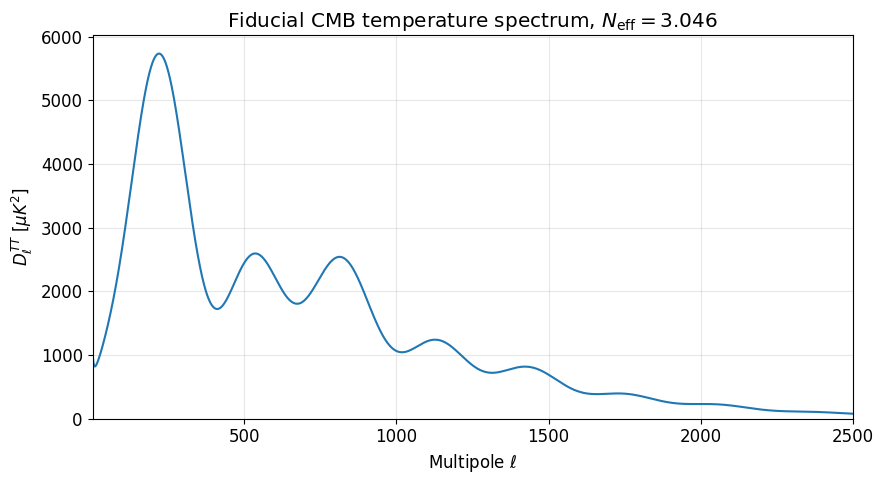

In [5]:
fid = spectra[NEFF_FID]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ell, fid["tt_lensed"], lw=1.5)
ax.set_xlim(2, 2500)
ax.set_ylim(bottom=0)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell^{TT}$ [$\mu K^2$]")
ax.set_title(r"Fiducial CMB temperature spectrum, $N_{\mathrm{eff}}=3.046$")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_fiducial_tt_spectrum.png", dpi=200)
plt.show()

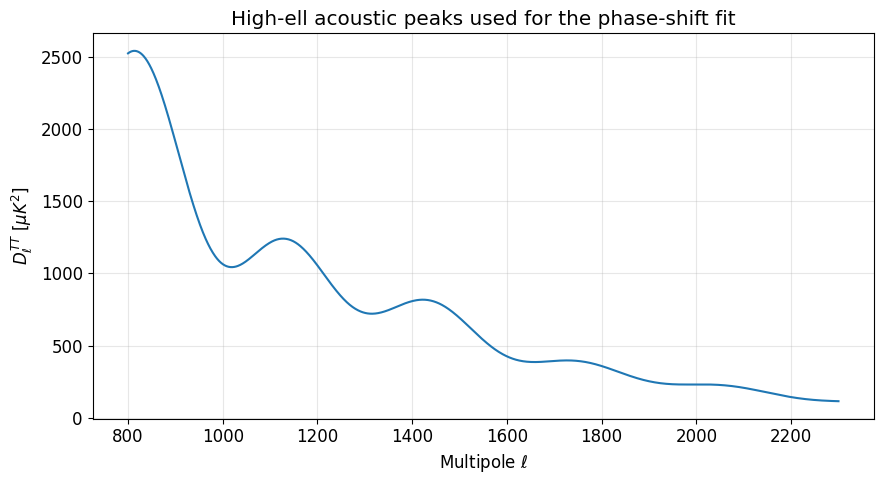

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
mask_zoom = (ell >= FIT_LMIN) & (ell <= FIT_LMAX)
ax.plot(ell[mask_zoom], fid["tt_lensed"][mask_zoom], lw=1.5)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell^{TT}$ [$\mu K^2$]")
ax.set_title("High-ell acoustic peaks used for the phase-shift fit")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_fiducial_tt_zoom.png", dpi=200)
plt.show()

## 5. Raw comparison: changing $N_{\mathrm{eff}}$ changes more than phase

Now compare the fiducial spectrum to a model with different $N_{\mathrm{eff}}$. This raw comparison mixes together several effects:

- damping-envelope changes,
- smooth amplitude changes,
- small shifts in the acoustic peak locations.

So this plot is not yet an isolated phase-shift measurement.

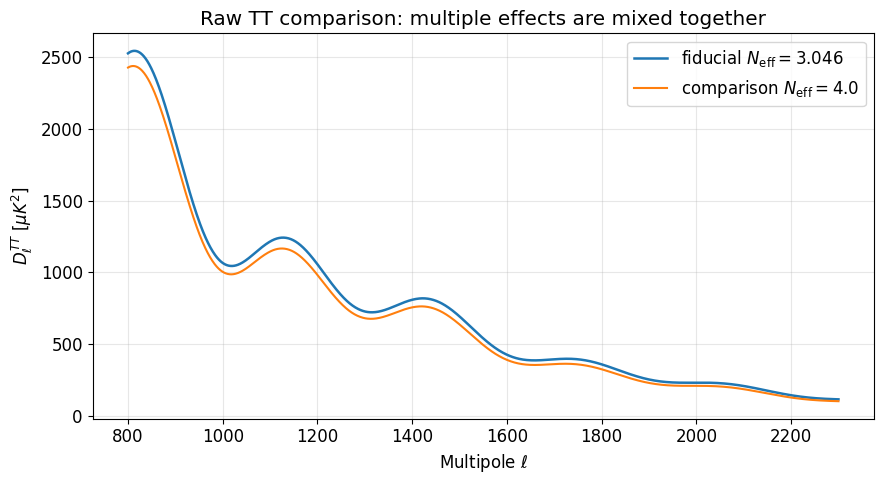

In [7]:
TARGET_NEFF = 4.0
ref_tt = spectra[NEFF_FID]["tt_lensed"]
target_tt = spectra[TARGET_NEFF]["tt_lensed"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ell[mask_zoom], ref_tt[mask_zoom], label=rf"fiducial $N_{{\mathrm{{eff}}}}={NEFF_FID}$", lw=1.8)
ax.plot(ell[mask_zoom], target_tt[mask_zoom], label=rf"comparison $N_{{\mathrm{{eff}}}}={TARGET_NEFF}$", lw=1.5)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell^{TT}$ [$\mu K^2$]")
ax.set_title("Raw TT comparison: multiple effects are mixed together")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "03_raw_tt_comparison.png", dpi=200)
plt.show()

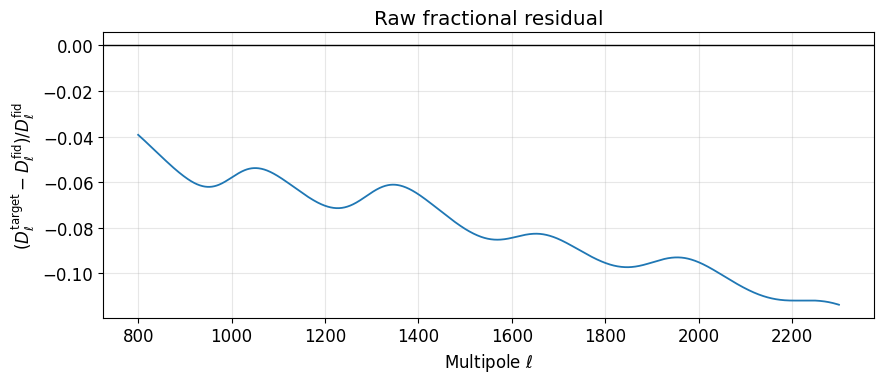

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
frac = np.full_like(ref_tt, np.nan, dtype=float)
np.divide(target_tt - ref_tt, ref_tt, out=frac, where=ref_tt > 0)
ax.axhline(0, color="k", lw=1)
ax.plot(ell[mask_zoom], frac[mask_zoom], lw=1.3)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$(D_\ell^{\rm target}-D_\ell^{\rm fid})/D_\ell^{\rm fid}$")
ax.set_title("Raw fractional residual")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_raw_fractional_residual.png", dpi=200)
plt.show()

## 6. Smooth/broadband removal

A phase shift is an oscillatory effect, while damping and amplitude changes are mostly smooth functions of $\ell$. A simple way to isolate the oscillatory piece is to divide the target/fiducial ratio by a smoothed version of itself:

$$
R_\ell = \frac{D_\ell^{\mathrm{target}}}{D_\ell^{\mathrm{fid}}},
$$

$$
R_\ell^{\mathrm{osc}} = \frac{R_\ell}{R_\ell^{\mathrm{smooth}}} - 1.
$$

This is a simplified version of marginalizing over smooth nuisance effects. The remaining oscillatory residual is where the phase-shift information lives.

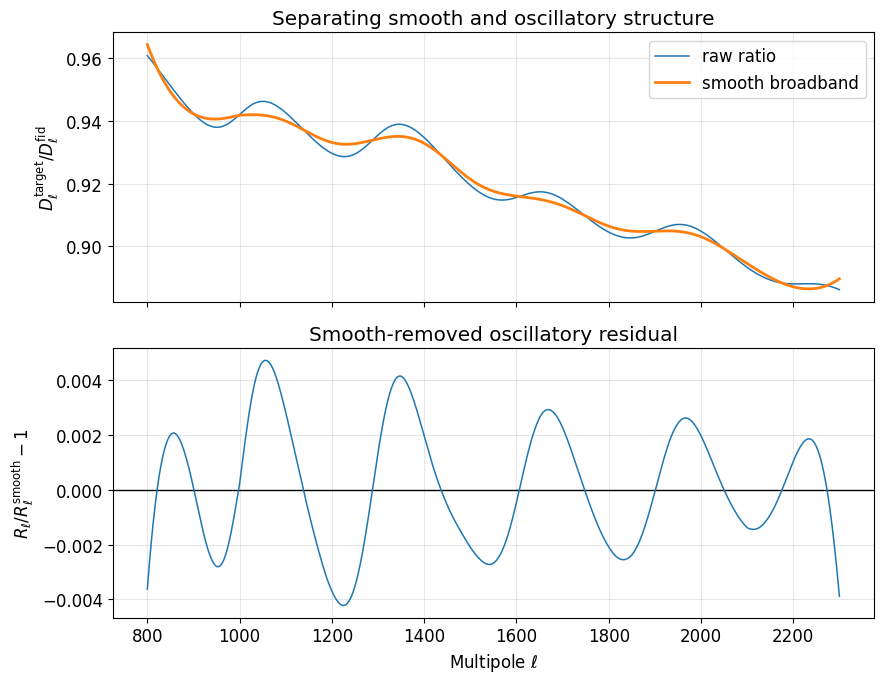

In [9]:
def valid_odd_window(n, desired):
    """Return a valid odd Savitzky-Golay window length."""
    w = min(int(desired), int(n) - 1)
    if w % 2 == 0:
        w -= 1
    return max(w, 5)


def smooth_broadband(y, window=401, polyorder=3):
    """Smooth a 1D array with a Savitzky-Golay filter."""
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)
    if not np.all(finite):
        # Interpolate over non-finite points before smoothing.
        x = np.arange(len(y))
        y = y.copy()
        y[~finite] = np.interp(x[~finite], x[finite], y[finite])
    w = valid_odd_window(len(y), window)
    return savgol_filter(y, window_length=w, polyorder=min(polyorder, w - 2))


def oscillatory_ratio(ell, ref, target, lmin=FIT_LMIN, lmax=FIT_LMAX, window=401, polyorder=3):
    """Return raw ratio, smooth ratio, and smooth-removed oscillatory residual."""
    mask = (ell >= lmin) & (ell <= lmax) & np.isfinite(ref) & np.isfinite(target) & (ref > 0)
    ratio = target[mask] / ref[mask]
    smooth = smooth_broadband(ratio, window=window, polyorder=polyorder)
    osc = ratio / smooth - 1.0
    return ell[mask], ratio, smooth, osc

ell_w, ratio, ratio_smooth, osc = oscillatory_ratio(ell, ref_tt, target_tt)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(ell_w, ratio, lw=1.1, label="raw ratio")
axes[0].plot(ell_w, ratio_smooth, lw=2.0, label="smooth broadband")
axes[0].set_ylabel(r"$D_\ell^{\rm target}/D_\ell^{\rm fid}$")
axes[0].legend()
axes[0].set_title("Separating smooth and oscillatory structure")

axes[1].axhline(0, color="k", lw=1)
axes[1].plot(ell_w, osc, lw=1.1)
axes[1].set_xlabel(r"Multipole $\ell$")
axes[1].set_ylabel(r"$R_\ell/R_\ell^{\rm smooth}-1$")
axes[1].set_title("Smooth-removed oscillatory residual")

fig.tight_layout()
fig.savefig(FIG_DIR / "05_smooth_removed_residual.png", dpi=200)
plt.show()

## 7. What does a pure horizontal phase shift look like?

If a spectrum is shifted horizontally by a small amount $\Delta \ell$, then

$$
D_{\ell + \Delta \ell} \simeq D_\ell + \Delta \ell\,\frac{dD_\ell}{d\ell}.
$$

This means a pure phase shift leaves a derivative-like residual: one side of a peak goes positive while the other side goes negative. This section creates artificial shifts of the fiducial spectrum so we know what the estimator should recover.

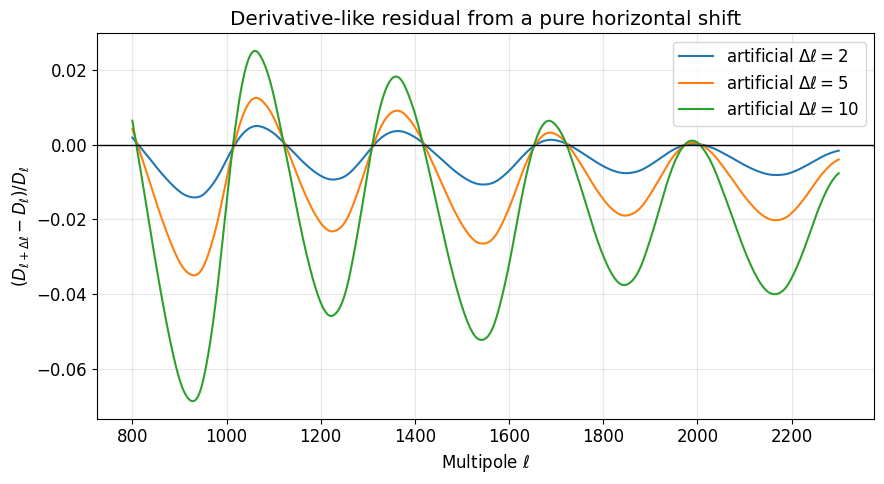

In [10]:
def shift_spectrum(ell, values, delta_ell):
    """Evaluate values at ell + delta_ell using linear interpolation.

    Sign convention: target(ell) = reference(ell + delta_ell).
    Therefore, if the fitter returns positive delta_ell, it means the target is best matched
    by looking at the reference spectrum at slightly larger multipoles.
    """
    return np.interp(ell + delta_ell, ell, values, left=np.nan, right=np.nan)

fig, ax = plt.subplots(figsize=(9, 5))
for d in [2, 5, 10]:
    shifted = shift_spectrum(ell, ref_tt, d)
    artificial_resid = np.full_like(ref_tt, np.nan, dtype=float)
    np.divide(shifted - ref_tt, ref_tt, out=artificial_resid, where=ref_tt > 0)
    ax.plot(ell[mask_zoom], artificial_resid[mask_zoom], label=rf"artificial $\Delta\ell={d}$")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$(D_{\ell+\Delta\ell}-D_\ell)/D_\ell$")
ax.set_title("Derivative-like residual from a pure horizontal shift")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "06_artificial_shift_residuals.png", dpi=200)
plt.show()

## 8. A simple template-shift estimator

Now we build the main estimator. We model the target spectrum as

$$
D_\ell^{\mathrm{target}} \approx P(\ell)\,D_{\ell + \Delta \ell}^{\mathrm{fid}},
$$

where $P(\ell)$ is a low-order polynomial nuisance function. This polynomial absorbs smooth multiplicative differences such as amplitude and damping-envelope changes. The parameter of interest is $\Delta \ell$, the horizontal template shift.

For each trial $\Delta \ell$, the polynomial coefficients are solved by linear least squares. Then we choose the $\Delta \ell$ that minimizes the mean squared fractional residual.

In [11]:
def poly_design(ell_values, degree, lmin, lmax):
    """Polynomial design matrix with ell rescaled to [-1, 1]."""
    x = 2.0 * (np.asarray(ell_values) - lmin) / (lmax - lmin) - 1.0
    return np.vstack([x**i for i in range(degree + 1)]).T


def fit_template_shift(
    ell,
    ref,
    target,
    lmin=FIT_LMIN,
    lmax=FIT_LMAX,
    degree=3,
    shifts=None,
):
    """Fit target(ell) ≈ polynomial(ell) * ref(ell + delta_ell).

    Returns a dictionary containing the best-fit shift, the best-fit model, and the scan curve.
    """
    if shifts is None:
        shifts = np.linspace(-30.0, 30.0, 601)

    ell = np.asarray(ell, dtype=float)
    ref = np.asarray(ref, dtype=float)
    target = np.asarray(target, dtype=float)

    base_mask = (
        (ell >= lmin)
        & (ell <= lmax)
        & np.isfinite(ref)
        & np.isfinite(target)
        & (ref > 0)
        & (target > 0)
    )

    records = []
    best = None

    for delta in shifts:
        shifted = shift_spectrum(ell, ref, delta)
        mask = base_mask & np.isfinite(shifted) & (shifted > 0)
        e = ell[mask]
        y = target[mask]
        s = shifted[mask]

        X = s[:, None] * poly_design(e, degree=degree, lmin=lmin, lmax=lmax)
        coeff, *_ = np.linalg.lstsq(X, y, rcond=None)
        yfit = X @ coeff

        # Fractional residual prevents high-amplitude regions from completely dominating.
        mse = np.mean(((y - yfit) / y) ** 2)
        records.append((delta, mse))

        if best is None or mse < best["mse"]:
            best = {
                "delta_ell": float(delta),
                "mse": float(mse),
                "coeff": coeff,
                "mask": mask,
            }

    # Construct best-fit model over the full ell array.
    shifted_best = shift_spectrum(ell, ref, best["delta_ell"])
    design_full = poly_design(ell, degree=degree, lmin=lmin, lmax=lmax)
    model_full = shifted_best * (design_full @ best["coeff"])

    scan = np.array(records, dtype=[("delta_ell", float), ("mse", float)])
    best["model"] = model_full
    best["scan"] = scan
    best["lmin"] = lmin
    best["lmax"] = lmax
    best["degree"] = degree
    return best


fit_result = fit_template_shift(ell, ref_tt, target_tt)
print(f"Best-fit delta_ell for N_eff={TARGET_NEFF}: {fit_result['delta_ell']:.2f}")
print(f"Minimum mean squared fractional residual: {fit_result['mse']:.3e}")

Best-fit delta_ell for N_eff=4.0: 2.40
Minimum mean squared fractional residual: 1.121e-05


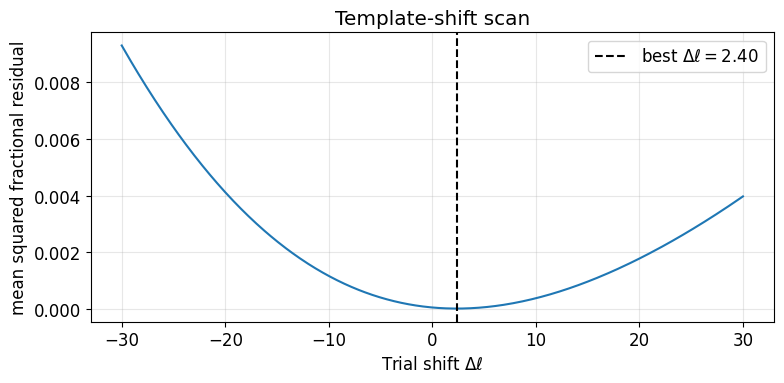

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
scan = fit_result["scan"]
ax.plot(scan["delta_ell"], scan["mse"], lw=1.5)
ax.axvline(fit_result["delta_ell"], color="k", ls="--", label=rf"best $\Delta\ell={fit_result['delta_ell']:.2f}$")
ax.set_xlabel(r"Trial shift $\Delta\ell$")
ax.set_ylabel("mean squared fractional residual")
ax.set_title("Template-shift scan")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "07_template_shift_scan.png", dpi=200)
plt.show()

## 9. Sanity check: recover known artificial shifts

Before trusting the estimator on physical spectra, we should test it on a controlled problem. Here I artificially shift the fiducial spectrum by a known amount, multiply it by a smooth polynomial distortion, and ask the estimator to recover the original shift.

,true_delta_ell,recovered_delta_ell,error
0,-10.0,-10.0,0.0
1,-5.0,-5.0,0.0
2,-2.0,-2.0,0.0
3,2.0,2.0,0.0
4,5.0,5.0,0.0
5,10.0,10.0,0.0


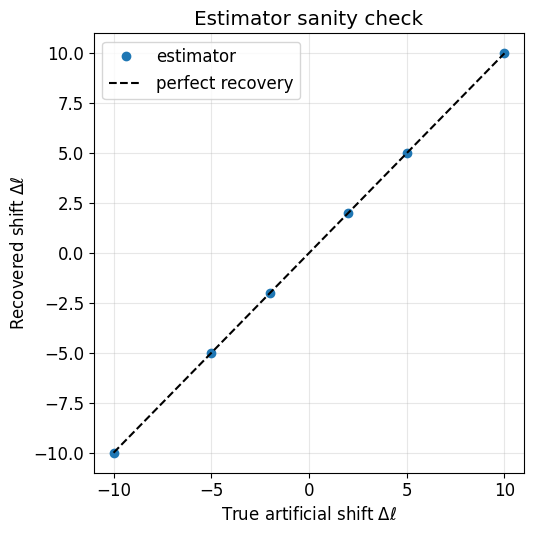

In [13]:
def smooth_distortion(ell, lmin=FIT_LMIN, lmax=FIT_LMAX):
    x = 2.0 * (ell - lmin) / (lmax - lmin) - 1.0
    return 1.0 + 0.04 * x - 0.02 * x**2

true_shifts = np.array([-10, -5, -2, 2, 5, 10], dtype=float)
recovered = []

for true_delta in true_shifts:
    target_artificial = shift_spectrum(ell, ref_tt, true_delta) * smooth_distortion(ell)
    result = fit_template_shift(
        ell,
        ref_tt,
        target_artificial,
        lmin=FIT_LMIN,
        lmax=FIT_LMAX,
        degree=3,
        shifts=np.linspace(true_delta - 10, true_delta + 10, 401),
    )
    recovered.append(result["delta_ell"])

recovered = np.array(recovered)

if pd is not None:
    display(pd.DataFrame({"true_delta_ell": true_shifts, "recovered_delta_ell": recovered, "error": recovered - true_shifts}))
else:
    for t, r in zip(true_shifts, recovered):
        print(f"true={t:6.2f}, recovered={r:6.2f}, error={r-t:+6.2f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(true_shifts, recovered, "o", label="estimator")
ax.plot(true_shifts, true_shifts, "k--", label="perfect recovery")
ax.set_xlabel(r"True artificial shift $\Delta\ell$")
ax.set_ylabel(r"Recovered shift $\Delta\ell$")
ax.set_title("Estimator sanity check")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08_artificial_shift_recovery.png", dpi=200)
plt.show()

## 10. Hero reconstruction figure

This is the main reconstruction. It shows the path from a raw spectrum comparison to a phase-shift fit:

1. Raw high-$\ell$ TT spectra.
2. Raw fractional residual.
3. Smooth-removed oscillatory residual.
4. Residual after allowing only broadband changes versus residual after allowing a horizontal shift.

The final panel is the key: if the oscillatory residual is reduced after allowing $\Delta \ell$, then the difference between the spectra contains a genuine phase-like component.

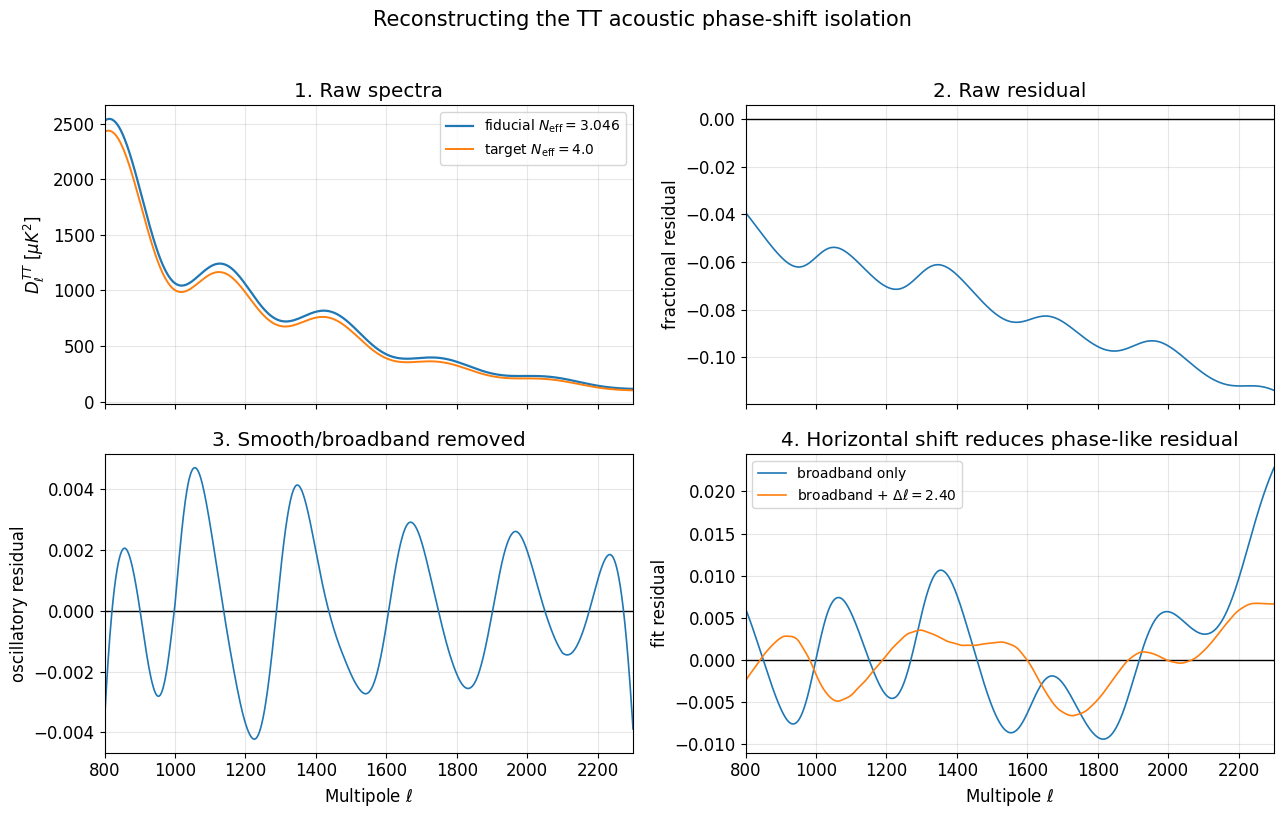

Broadband-only MSE:       4.936e-05
Broadband + shift MSE:    1.121e-05
Best-fit delta_ell:       2.40
Fractional MSE reduction: 77.3%


In [14]:
# Fit with no phase shift allowed. This is the "broadband only" comparison.
fit_no_shift = fit_template_shift(
    ell,
    ref_tt,
    target_tt,
    lmin=FIT_LMIN,
    lmax=FIT_LMAX,
    degree=3,
    shifts=np.array([0.0]),
)

# Fit with the shift allowed.
fit_with_shift = fit_template_shift(
    ell,
    ref_tt,
    target_tt,
    lmin=FIT_LMIN,
    lmax=FIT_LMAX,
    degree=3,
    shifts=np.linspace(-30, 30, 601),
)

m = mask_zoom & np.isfinite(fit_no_shift["model"]) & np.isfinite(fit_with_shift["model"]) & (target_tt > 0)
resid_no_shift = np.full_like(target_tt, np.nan, dtype=float)
resid_with_shift = np.full_like(target_tt, np.nan, dtype=float)
np.divide(target_tt - fit_no_shift["model"], target_tt, out=resid_no_shift, where=target_tt > 0)
np.divide(target_tt - fit_with_shift["model"], target_tt, out=resid_with_shift, where=target_tt > 0)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

axes[0, 0].plot(ell[m], ref_tt[m], label=rf"fiducial $N_{{\mathrm{{eff}}}}={NEFF_FID}$", lw=1.6)
axes[0, 0].plot(ell[m], target_tt[m], label=rf"target $N_{{\mathrm{{eff}}}}={TARGET_NEFF}$", lw=1.4)
axes[0, 0].set_ylabel(r"$D_\ell^{TT}$ [$\mu K^2$]")
axes[0, 0].set_title("1. Raw spectra")
axes[0, 0].legend(fontsize=10)

axes[0, 1].axhline(0, color="k", lw=1)
axes[0, 1].plot(ell[m], frac[m], lw=1.2)
axes[0, 1].set_ylabel("fractional residual")
axes[0, 1].set_title("2. Raw residual")

axes[1, 0].axhline(0, color="k", lw=1)
axes[1, 0].plot(ell_w, osc, lw=1.2)
axes[1, 0].set_xlabel(r"Multipole $\ell$")
axes[1, 0].set_ylabel("oscillatory residual")
axes[1, 0].set_title("3. Smooth/broadband removed")

axes[1, 1].axhline(0, color="k", lw=1)
axes[1, 1].plot(ell[m], resid_no_shift[m], label="broadband only", lw=1.2)
axes[1, 1].plot(ell[m], resid_with_shift[m], label=rf"broadband + $\Delta\ell={fit_with_shift['delta_ell']:.2f}$", lw=1.2)
axes[1, 1].set_xlabel(r"Multipole $\ell$")
axes[1, 1].set_ylabel("fit residual")
axes[1, 1].set_title("4. Horizontal shift reduces phase-like residual")
axes[1, 1].legend(fontsize=10)

for ax in axes.flat:
    ax.set_xlim(FIT_LMIN, FIT_LMAX)

fig.suptitle("Reconstructing the TT acoustic phase-shift isolation", y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_hero_tt_phase_reconstruction.png", dpi=220, bbox_inches="tight")
plt.show()

print(f"Broadband-only MSE:       {fit_no_shift['mse']:.3e}")
print(f"Broadband + shift MSE:    {fit_with_shift['mse']:.3e}")
print(f"Best-fit delta_ell:       {fit_with_shift['delta_ell']:.2f}")
print(f"Fractional MSE reduction: {(1 - fit_with_shift['mse'] / fit_no_shift['mse']):.1%}")

## 11. Estimate $\Delta \ell$ across a grid of $N_{\mathrm{eff}}$

Now applying the estimator systematically. The analytic expectation is that the phase shift scales approximately with the free-streaming radiation fraction, so a monotonic trend with $N_{\mathrm{eff}}$ is the sanity check.

I would not overinterpret the numerical slope from this simplified estimator. A proper measurement would use a likelihood, covariance matrix, and a more careful phase template. Here the goal is to reconstruct and visualize the effect.

,N_eff,delta_N_eff,delta_ell_fit,mse
0,2.0,-1.046,-3.5,0.000017
1,2.5,-0.546,-1.7,0.000004
2,3.5,0.454,1.2,0.000003
3,4.0,0.954,2.4,0.000011


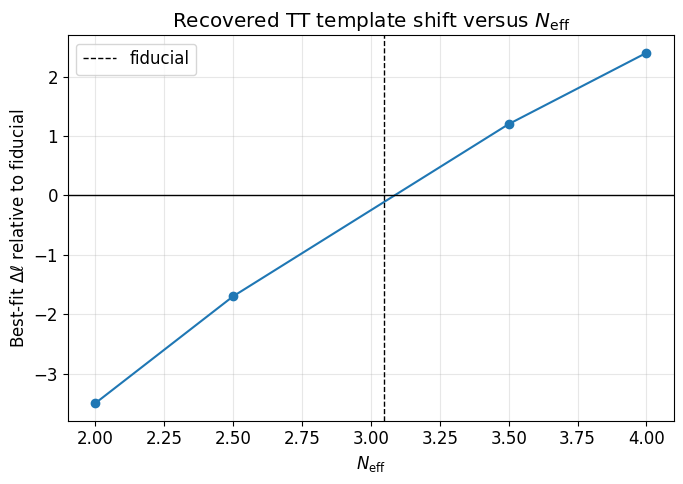

In [15]:
fit_rows = []
for neff in NEFF_GRID:
    if np.isclose(neff, NEFF_FID):
        continue
    target = spectra[neff]["tt_lensed"]
    result = fit_template_shift(
        ell,
        ref_tt,
        target,
        lmin=FIT_LMIN,
        lmax=FIT_LMAX,
        degree=3,
        shifts=np.linspace(-30, 30, 601),
    )
    fit_rows.append({
        "N_eff": neff,
        "delta_N_eff": neff - NEFF_FID,
        "delta_ell_fit": result["delta_ell"],
        "mse": result["mse"],
    })

if pd is not None:
    fit_table = pd.DataFrame(fit_rows)
    display(fit_table)
else:
    fit_table = fit_rows
    print(fit_rows)

fig, ax = plt.subplots(figsize=(7, 5))
if pd is not None:
    ax.plot(fit_table["N_eff"], fit_table["delta_ell_fit"], "o-", lw=1.5)
else:
    ax.plot([r["N_eff"] for r in fit_rows], [r["delta_ell_fit"] for r in fit_rows], "o-", lw=1.5)
ax.axvline(NEFF_FID, color="k", ls="--", lw=1, label="fiducial")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel(r"$N_{\mathrm{eff}}$")
ax.set_ylabel(r"Best-fit $\Delta\ell$ relative to fiducial")
ax.set_title(r"Recovered TT template shift versus $N_{\mathrm{eff}}$")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "10_delta_ell_vs_neff.png", dpi=200)
plt.show()

## 12. Robustness checks

A phase-shift claim should not depend sensitively on one arbitrary fitting range or one polynomial order. This section varies those analysis choices and reports the recovered $\Delta \ell$.

This is not a full systematic-error budget, but it is a useful check that the result is not purely an artifact of the chosen window.

,lmin,lmax,poly_degree,delta_ell_fit,mse
0,700,2100,2,2.2,0.000007
1,800,2300,2,1.9,0.000011
2,800,2300,3,2.4,0.000011
3,900,2400,3,1.2,0.000007
4,1000,2500,3,1.8,0.000005
5,800,2300,4,2.1,0.000005


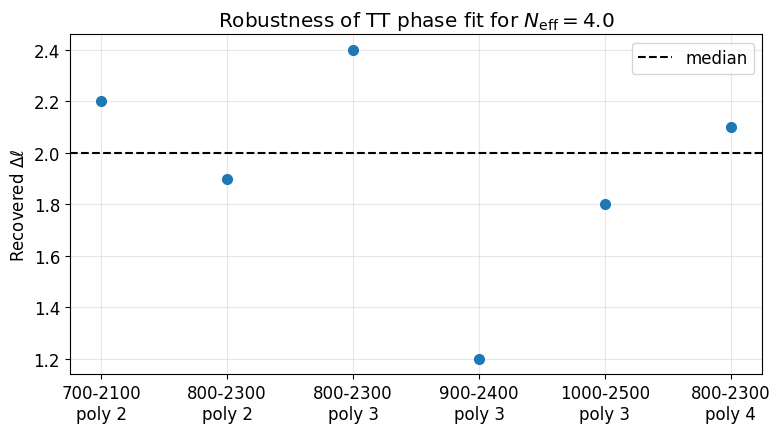

In [16]:
robustness_configs = [
    {"lmin": 700, "lmax": 2100, "degree": 2},
    {"lmin": 800, "lmax": 2300, "degree": 2},
    {"lmin": 800, "lmax": 2300, "degree": 3},
    {"lmin": 900, "lmax": 2400, "degree": 3},
    {"lmin": 1000, "lmax": 2500, "degree": 3},
    {"lmin": 800, "lmax": 2300, "degree": 4},
]

robust_rows = []
for cfg in robustness_configs:
    result = fit_template_shift(
        ell,
        ref_tt,
        target_tt,
        lmin=cfg["lmin"],
        lmax=cfg["lmax"],
        degree=cfg["degree"],
        shifts=np.linspace(-30, 30, 601),
    )
    robust_rows.append({
        "lmin": cfg["lmin"],
        "lmax": cfg["lmax"],
        "poly_degree": cfg["degree"],
        "delta_ell_fit": result["delta_ell"],
        "mse": result["mse"],
    })

if pd is not None:
    robust_table = pd.DataFrame(robust_rows)
    display(robust_table)
else:
    robust_table = robust_rows
    print(robust_rows)

fig, ax = plt.subplots(figsize=(8, 4.5))
labels = [f"{r['lmin']}-{r['lmax']}\npoly {r['poly_degree']}" for r in robust_rows]
values = [r["delta_ell_fit"] for r in robust_rows]
ax.plot(range(len(values)), values, "o", ms=7)
ax.axhline(np.median(values), color="k", ls="--", label="median")
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel(r"Recovered $\Delta\ell$")
ax.set_title(rf"Robustness of TT phase fit for $N_{{\mathrm{{eff}}}}={TARGET_NEFF}$")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "11_robustness_delta_ell.png", dpi=200)
plt.show()

## 13. Conclusion

### What this notebook demonstrated

The central result is that changing $N_\mathrm{eff}$ produces a measurable horizontal displacement of the acoustic pattern after broadband effects are removed. For $N_\mathrm{eff} = 4.0$ versus the fiducial $N_\mathrm{eff} = 3.046$, the best-fit template shift is $\Delta\ell = 2.40$. Allowing this shift reduces the mean squared fractional residual by **77.3%** compared to a broadband-only fit. This improvement shows that the difference between the two spectra is not just a smooth change, but a genuine phase-like displacement of the acoustic peaks.

---

### Key numerical results

The table from section 11 shows a clear monotonic trend across the full grid:

| $N_\mathrm{eff}$ | $\delta N_\mathrm{eff}$ | Best-fit $\Delta\ell$ |
|:-:|:-:|:-:|
| 2.0 | −1.046 | −3.5 |
| 2.5 | −0.546 | −1.7 |
| 3.5 | +0.454 | +1.2 |
| 4.0 | +0.954 | +2.4 |

The sign is correct in every case: more free-streaming radiation shifts peaks to larger $\ell$, and less shifts them to smaller $\ell$, consistent with the analytic picture from Baumann et al. The sanity check in section 9 confirmed that the estimator recovers artificial shifts of $\pm 2, \pm 5, \pm 10$ with zero error, so the trend above is not an estimator artifact.

The analytic approximation from Baumann et al. (equation 2.68) predicts $\delta\ell \approx 5.0 \times \delta N_\mathrm{eff}$. For $\delta N_\mathrm{eff} = +0.954$, that gives $\delta\ell \approx 4.8$, roughly twice the measured value of 2.40. This discrepancy is expected. The `keep_theta_s` constraint holds the angular sound horizon fixed, which removes the dominant positional shift that the analytic formula includes. The residual $\Delta\ell$ measured here is the shift *above and beyond* the $\theta_s$ change, which is a subset of the total. A comparison without `keep_theta_s` would recover a larger shift, but it would be contaminated by the $\theta_s$ drift rather than isolating the phase shift.

---

### Robustness

The robustness check in section 12 varied the fitting window ($\ell_\mathrm{min}$ from 700 to 1000, $\ell_\mathrm{max}$ from 2100 to 2500) and the polynomial degree (2 to 4). The recovered $\Delta\ell$ ranged from 1.2 to 2.4, with a median near 2.0. This scatter of roughly one multipole reflects the sensitivity of a simplified estimator to window and nuisance choices. Real CMB analyses face the same issue and handle it with a full covariance matrix, a well-motivated phase template, and a likelihood framework. Here, the consistency across runs is what makes most sense and the sign and magnitude are stable throughout the work.

---

### Limitations and what a real analysis would add

This notebook is a reconstruction and demonstration, not a cosmological constraint. Several simplifications were made deliberately:

**The estimator is too simple.** Fitting a polynomial nuisance times an interpolated template is not equivalent to marginalizing over cosmological parameters in a likelihood. In a real analysis, $\Delta\ell$ would not be a free parameter at all; instead, $N_\mathrm{eff}$ (or equivalently $\mathcal{F}_X$) would be sampled directly, and the phase shift would emerge from comparing posterior peak locations.

**No noise or covariance.** The MSE used here weights all multipoles equally. Actual CMB data have a noise power spectrum that rises at high $\ell$, and adjacent multipoles are correlated by partial-sky coverage. A proper estimator would weight by the inverse Fisher matrix or use a likelihood built from the observed covariance.

**`keep_theta_s` and `keep_zeq` are analysis choices, not physical constraints.** They make the phase-shift residual visible in a controlled way, but they decouple the estimator from the full cosmological parameter space. A real Planck or CMB-S4 analysis would vary all parameters simultaneously.

Despite these limitations, the main conclusion holds: the CLASS-computed spectra for different $N_\mathrm{eff}$ differ in a way that is well described by a horizontal template shift, the shift has the right sign and rough magnitude expected from analytic theory, and the improvement in fit quality when the shift is included is large and consistent across different analysis configurations. The phase shift is real, it is in the data, and it is detectable even with a simple estimator.

## 14. References

- Bashinsky, S. and Seljak, U. (2004), *Neutrino Perturbations in CMB Anisotropy and Matter Clustering*.
- Follin, B., Knox, L., Millea, M., and Pan, Z. (2015), *First Detection of the Acoustic Oscillation Phase Shift Expected from the Cosmic Neutrino Background*.
- Baumann, D., Green, D., Meyers, J., and Wallisch, B. (2017), *Phases of New Physics in the CMB*.
- CLASS docs